In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
base_path = Path(r"C:\Users\Kamil\Desktop\Kamil i jego pliki\ml-wakacyjne-wyzwanie-2026\01_przetwarzanie_wizualizacja_danych") # change to path folder with data


# Analiza i przetwarzanie danych na temat Titanica

#### Wyobraź sobie, że pewnego wakacyjnego dnia, będąc na plaży w pełnym słońcu, odbierasz telefon od nieznanego numeru.
Robisz to niechętnie — zasłużyłeś/aś przecież na odpoczynek i chcesz mieć ten czas tylko dla siebie. Już masz na końcu języka wymijającą odpowiedź, gdy nagle z drugiej strony słyszysz:
„Czy jesteś gotowy, by tego lata rozwikłać jedną z największych zagadek ludzkości?”

Jako osoba z natury ciekawa świata i ze świetnym umysłem analitycznym, szybko zapominasz o plaży i wakacjach. Zaintrygowany/a dopytujesz o szczegóły, ale rozmówca nie chce zdradzić zbyt wiele. Wiadomo jedynie, że chodzi o *zatonięcie Titanica w 1914* roku, a celem misji jest ustalenie, które osoby miały szansę przeżyć.

**Ty** — jako **renomowany analityk danych** — byłeś/byłaś ich pierwszym wyborem do analizy i oczyszczenia danych. Mimo wątpliwości postanawiasz podjąć się zadania, mając nadzieję, że twoja wiedza może zostać praktycznie wykorzystana w słusznym celu.

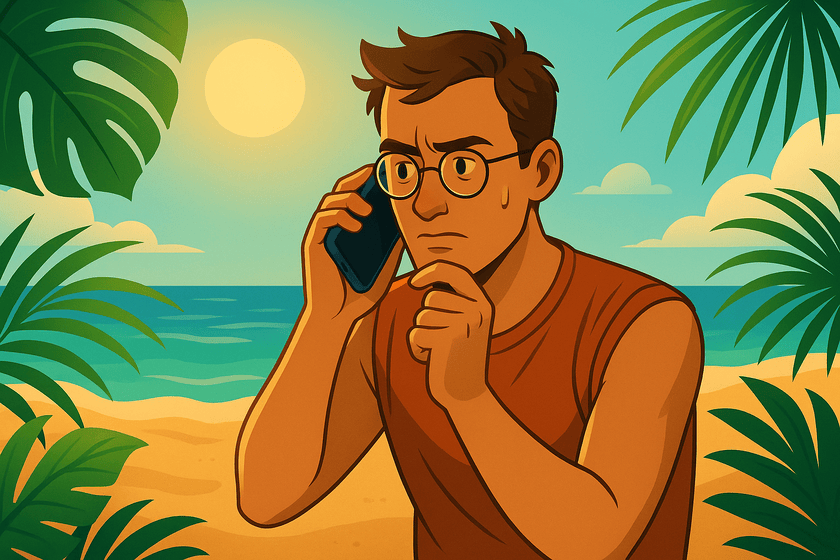

(*AI-generated image*)


#### Twoim celem będzie przeanalizowanie i przetworzenie zbioru danych w taki sposób, by mógł on być użyty do nauki modelu do klasyfikacji każdego pasażera Titanica jako ofiary (0) lub osoby, która przeżyła (1).

(Uwaga: w tym zadaniu nie będziesz trenować modeli, ta przyjemność spotka cię w następnych notebookach)

Poniżej znajdziesz pytania, które mogą być pomocne w analizie, oraz odwołania do poszczególnych sekcji z notebooka do lekcji:

- Czy wszystkie kolumny są istotne w kontekście zadania?
- Czy występują brakujące wartości? Jeśli tak, to jak je uzupełnisz? (sekcja #2.1)
- Czy typy danych są odpowiednie do znaczenia kolumny? (sekcja #1.3)
- Czy dystrybucje danych mają rozkłady normalne, czy asymetryczne? (sekcja #4.1 + wykład)
- Która zmienna oznacza predykowaną klasę?
- Jaki jest rozkład zmiennej predykowanej względem zmiennych kategorialnych, jak i numerycznych? (sekcja #4.1)
- Czy końcowe rozkłady zawierają wartości skrajne? (sekcja #4.2 + wykład)

Wymagania:

- Zbiór musi być oczyszczony, tj. finalnie nie powinien mieć brakujących wartości (sekcja #2.1)
- Zbiór musi zawierać co najmniej dwie dodatkowe kolumny, które mogą wzbogacić informacje zawarte w zbiorze (sekcje #1.5 i #2.2)
- Cechy kategorialne powinny być zakodowane, postaraj się dobrać odpowiedni sposób (sekcja #2.3)
- Zbadaj, czy występują skrajne wartości (outliery) zarówno dla wartości numerycznych, jak i dla kategorialnych
- Każda cecha powinna być zwizualizowana co najmniej raz. Sam(a) zastanów się, czy warto wizualizować cechy parami w celu odkrycia zależności między nimi (sekcja #4.4)
- Nie ma ograniczenia na liczbę komórek, ale zastanów się, czy dana wizualizacja/obliczenie jest przydatne w całej analizie, czy po prostu sobie "egzystuje" bez żadnych wniosków

Zadbaj o czytelność kodu i nazewnictwo zmiennych. Jeśli jakiś wycinek kodu się powtarza, to wyodrębnij go do funkcji. Postaraj się zamieszczać swoje wnioski w postaci komentarza `Markdown`.

Poniżej zamieszczamy tabelę z wyjaśnieniem poszczególnych kolumn:

| Kolumna      | Opis                                                                            |
| ------------ | ------------------------------------------------------------------------------- |
| **Survived** | Czy pasażer przeżył (0 = nie, 1 = tak).                                         |
| **Pclass**   | Klasa podróży (1 = I klasa, 2 = II klasa, 3 = III klasa).                       |
| **Name**     | Imię i nazwisko pasażera.                                                       |
| **Sex**      | Płeć pasażera (male = mężczyzna, female = kobieta).                             |
| **Age**      | Wiek pasażera w latach.                                                         |
| **SibSp**    | Liczba rodzeństwa i małżonków na pokładzie.                                     |
| **Parch**    | Liczba rodziców i dzieci na pokładzie.                                          |
| **Ticket**   | Numer biletu.                                                                   |
| **Fare**     | Cena biletu.                                                                    |
| **Cabin**    | Numer kabiny pasażera                                     |
| **Embarked** | Port, w którym pasażer wsiadł (C = Cherbourg, Q = Queenstown, S = Southampton). |
                                                         |


In [2]:
titanic_df = pd.read_csv(base_path / 'titanic.csv', index_col='PassengerId')

In [3]:
print(titanic_df.Survived.value_counts(normalize=True))

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


In [4]:
print(titanic_df.isna().sum())

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare         98
Cabin       687
Embarked      2
dtype: int64


In [5]:
def get_percentage_missing(df, axis):
  missing_rows = df.isna().sum(axis=axis)
  missing_rows_perc = np.round(missing_rows / df.shape[axis] * 100, 2)
  return missing_rows_perc[missing_rows_perc > 0]
missing_cols_mi = get_percentage_missing(titanic_df, axis=0)
print(missing_cols_mi)

Age         19.87
Fare        11.00
Cabin       77.10
Embarked     0.22
dtype: float64


Z podanych wartości dochodzę do wniosku, że cechy takie jak wiek i numer kabiny pasażera są ważne w kontekście przeżycia katastrofy, zatem będę chciał je odpowiednio uzupełnić. Co do ceny biletu i miasta, z którego pasażerowie wsiadali nie jest to istotne. W przypadku ceny dodam wartości jako medianę jeśli rozkład danych wyjdzie asymetryczny, a dla miast nie byłoby to optymalne dodać kolejny typ wartości jak 'Unknown', skoro brakujących odpowiedzi jest tylko dwie. Tam uzupełnię wartości modą.


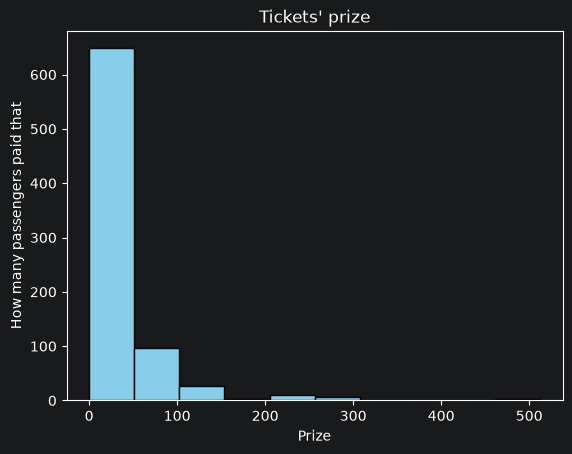

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
Embarked      0
dtype: int64

In [6]:
data = titanic_df.Fare

plt.hist(data, bins=10, color='skyblue', edgecolor='black')
plt.title("Tickets' prize")
plt.xlabel("Prize")
plt.ylabel("How many passengers paid that")
plt.show()
#print(titanic_df['Fare'].median())
titanic_df['Fare'] = titanic_df['Fare'].fillna(titanic_df['Fare'].median())
#print(titanic_df['Embarked'].mode())
titanic_df['Embarked'] = titanic_df['Embarked'].fillna(titanic_df['Embarked'].mode()[0])
titanic_df.isna().sum()

 Do uzupełnienia pustych pól kategorii wieku zastosuję metodę losowania na podstawie rozkładu danych niebrakujących.

In [7]:
def get_column_distribution(df, column):
  return df[column].value_counts(normalize=True)
age_count_prob = get_column_distribution(titanic_df, 'Age')
print(age_count_prob)

age_values = age_count_prob.index
age_probs = age_count_prob.values

missing_age_vals = titanic_df.Age.isna()
titanic_df.loc[missing_age_vals, 'Age'] = np.random.choice(age_values, size=missing_age_vals.sum(), p=age_probs)
age_count_prob=get_column_distribution(titanic_df, 'Age')
print(age_count_prob)
titanic_df.isna().sum()

Age
24.00    0.042017
22.00    0.037815
18.00    0.036415
28.00    0.035014
19.00    0.035014
           ...   
24.50    0.001401
0.67     0.001401
0.42     0.001401
34.50    0.001401
74.00    0.001401
Name: proportion, Length: 88, dtype: float64
Age
22.00    0.041526
24.00    0.039282
28.00    0.035915
18.00    0.035915
30.00    0.033670
           ...   
80.00    0.001122
24.50    0.001122
0.42     0.001122
34.50    0.001122
74.00    0.001122
Name: proportion, Length: 88, dtype: float64


Survived      0
Pclass        0
Name          0
Sex           0
Age           0
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
Embarked      0
dtype: int64

Jeśli chodzi o numer kabiny, najlepiej dodać wartości 'Unknown', ponieważ aż 77% osoób nie udzieliło odpowiedzi na to pytanie.

In [8]:
titanic_df['Cabin'] = titanic_df['Cabin'].fillna('Unknown')
titanic_df.isna().sum()

Survived    0
Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Ticket      0
Fare        0
Cabin       0
Embarked    0
dtype: int64

Przechodzę do dodania nowych przydatnych kolumn. Pierwszą z nich będzie kolumna Family_members, która będzie łatwiejsza do analizy czy jej wartości miały wpływ na przeżycie niż analiza osobno kolumny o rodzicach i dzieciach a osobno o małżonkach i rodzeństwie.

In [9]:
titanic_df['Family_members']=titanic_df['SibSp']+titanic_df['Parch']
print(titanic_df[['Family_members','SibSp','Parch']])

             Family_members  SibSp  Parch
PassengerId                              
1                         1      1      0
2                         1      1      0
3                         0      0      0
4                         1      1      0
5                         0      0      0
...                     ...    ...    ...
887                       0      0      0
888                       0      0      0
889                       3      1      2
890                       0      0      0
891                       0      0      0

[891 rows x 3 columns]


Następna kolumna będzie pokazywać w jakiej grupie wiekowej znajdował się pasażer, to dobra analitycznie dana. Nazwa: Age_group. Przedziały wiekowe: do lat 17. -> dziecko, do lat 59. -> dorosły, od 60 lat -> senior.

In [10]:
age_groups = lambda x: 'child' if x < 18 else ('adult' if x < 60 else 'senior')
titanic_df['Age_group'] = titanic_df['Age'].apply(age_groups)
print(titanic_df[['Age', 'Age_group']].to_string())

               Age Age_group
PassengerId                 
1            22.00     adult
2            38.00     adult
3            26.00     adult
4            35.00     adult
5            35.00     adult
6            52.00     adult
7            54.00     adult
8             2.00     child
9            27.00     adult
10           14.00     child
11            4.00     child
12           58.00     adult
13           20.00     adult
14           39.00     adult
15           14.00     child
16           55.00     adult
17            2.00     child
18           41.00     adult
19           31.00     adult
20           29.00     adult
21           35.00     adult
22           34.00     adult
23           15.00     child
24           28.00     adult
25            8.00     child
26           38.00     adult
27            7.00     child
28           19.00     adult
29           19.00     adult
30           34.00     adult
31           40.00     adult
32           58.00     adult
33           4

Przechodzę do kodowania cech kategorialnych. Cecha Survived jest już zakodowana. Cecha dotycząca klasy również nie wymaga kodowania. Cecha imię i nazwisko jest w zasadzie zbędna. Jedyne sensowne kodowanie dla niej to Label, jednak kiedy istnieje kolumna z id pasażera, właściwie niepotrzebna jest ta dana, bo nie wpływa ona na to czy ktoś przeżył. Usuwam ją.

In [11]:
titanic_df=titanic_df.drop(columns=['Name'])
print(titanic_df)

             Survived  Pclass     Sex   Age  SibSp  Parch            Ticket  \
PassengerId                                                                   
1                   0       3    male  22.0      1      0         A/5 21171   
2                   1       1  female  38.0      1      0          PC 17599   
3                   1       3  female  26.0      0      0  STON/O2. 3101282   
4                   1       1  female  35.0      1      0            113803   
5                   0       3    male  35.0      0      0            373450   
...               ...     ...     ...   ...    ...    ...               ...   
887                 0       2    male  27.0      0      0            211536   
888                 1       1  female  19.0      0      0            112053   
889                 0       3  female  31.0      1      2        W./C. 6607   
890                 1       1    male  26.0      0      0            111369   
891                 0       3    male  32.0      0  

Kolumnę płci zakoduję sposobem binarnym.

In [12]:
titanic_df['Is_male'] = titanic_df.Sex.map({
    'male': 1, 'female': 0
})
#print(titanic_df)
titanic_df=titanic_df.drop(columns=['Sex'])
print(titanic_df)

             Survived  Pclass   Age  SibSp  Parch            Ticket     Fare  \
PassengerId                                                                    
1                   0       3  22.0      1      0         A/5 21171   7.2500   
2                   1       1  38.0      1      0          PC 17599  71.2833   
3                   1       3  26.0      0      0  STON/O2. 3101282   7.9250   
4                   1       1  35.0      1      0            113803  53.1000   
5                   0       3  35.0      0      0            373450   8.0500   
...               ...     ...   ...    ...    ...               ...      ...   
887                 0       2  27.0      0      0            211536  13.0000   
888                 1       1  19.0      0      0            112053  30.0000   
889                 0       3  31.0      1      2        W./C. 6607  23.4500   
890                 1       1  26.0      0      0            111369  30.0000   
891                 0       3  32.0     

Jeśli chodzi o bilety, to również można je usunąć. Nie da się z nich wyciągnąć wartościowych informacji.

In [13]:
#print(titanic_df['Ticket'].is_unique)
#print(titanic_df['Ticket'].value_counts()[titanic_df['Ticket'].value_counts() > 1]) sprawdzalem czy są one unikalne (z ciekawosci)
titanic_df=titanic_df.drop(columns=['Ticket'])
print(titanic_df)

             Survived  Pclass   Age  SibSp  Parch     Fare    Cabin Embarked  \
PassengerId                                                                    
1                   0       3  22.0      1      0   7.2500  Unknown        S   
2                   1       1  38.0      1      0  71.2833      C85        C   
3                   1       3  26.0      0      0   7.9250  Unknown        S   
4                   1       1  35.0      1      0  53.1000     C123        S   
5                   0       3  35.0      0      0   8.0500  Unknown        S   
...               ...     ...   ...    ...    ...      ...      ...      ...   
887                 0       2  27.0      0      0  13.0000  Unknown        S   
888                 1       1  19.0      0      0  30.0000      B42        S   
889                 0       3  31.0      1      2  23.4500  Unknown        S   
890                 1       1  26.0      0      0  30.0000     C148        C   
891                 0       3  32.0     

Kategoria Embarked -> Label coding (spróbuję jednak metodą binarną z małą modyfikacją). S->1, C->2, Q->3.

In [14]:
titanic_df['City_index'] = titanic_df.Embarked.map({
    'S': 1, 'C': 2, 'Q':3
})
#print(titanic_df)
titanic_df=titanic_df.drop(columns=['Embarked'])
print(titanic_df)

             Survived  Pclass   Age  SibSp  Parch     Fare    Cabin  \
PassengerId                                                           
1                   0       3  22.0      1      0   7.2500  Unknown   
2                   1       1  38.0      1      0  71.2833      C85   
3                   1       3  26.0      0      0   7.9250  Unknown   
4                   1       1  35.0      1      0  53.1000     C123   
5                   0       3  35.0      0      0   8.0500  Unknown   
...               ...     ...   ...    ...    ...      ...      ...   
887                 0       2  27.0      0      0  13.0000  Unknown   
888                 1       1  19.0      0      0  30.0000      B42   
889                 0       3  31.0      1      2  23.4500  Unknown   
890                 1       1  26.0      0      0  30.0000     C148   
891                 0       3  32.0      0      0   7.7500  Unknown   

             Family_members Age_group  Is_male  City_index  
PassengerId    

Zakodować muszę również kolumnę Age_group. Zdałem sobie sprawę, że mogłem od razu to zrobić, skoro i tak teraz ją usunę po zakodowaniu (rozumiem, że dane muszą być obrobione dla komputera, więc ma nie być żadnych danych kategorialnych tekstowych?)

In [15]:
titanic_df['Age_group_index'] = titanic_df.Age_group.map({
    'child': 1, 'adult': 2, 'senior':3
})
print(titanic_df)
titanic_df=titanic_df.drop(columns=['Age_group'])
print(titanic_df)

             Survived  Pclass   Age  SibSp  Parch     Fare    Cabin  \
PassengerId                                                           
1                   0       3  22.0      1      0   7.2500  Unknown   
2                   1       1  38.0      1      0  71.2833      C85   
3                   1       3  26.0      0      0   7.9250  Unknown   
4                   1       1  35.0      1      0  53.1000     C123   
5                   0       3  35.0      0      0   8.0500  Unknown   
...               ...     ...   ...    ...    ...      ...      ...   
887                 0       2  27.0      0      0  13.0000  Unknown   
888                 1       1  19.0      0      0  30.0000      B42   
889                 0       3  31.0      1      2  23.4500  Unknown   
890                 1       1  26.0      0      0  30.0000     C148   
891                 0       3  32.0      0      0   7.7500  Unknown   

             Family_members Age_group  Is_male  City_index  Age_group_index 

Zostaje jeszcze numer kabiny. Zastosuję One-hot coding dla pierwszych liter kabin. Przy okazji sprawdzę outliery i sprawdzę zależność z przeżywalnością. Po zakodowaniu byłoby to trudniejsze.

Cabin
U    0.771044
C    0.066218
B    0.052750
D    0.037037
E    0.035915
A    0.016835
F    0.014590
G    0.004489
T    0.001122
Name: proportion, dtype: float64


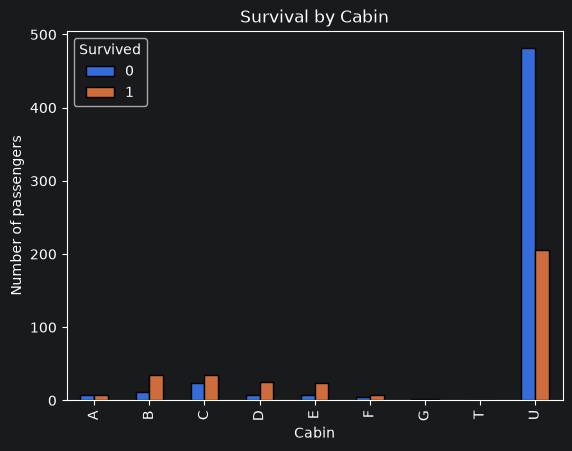

             Survived  Pclass   Age  SibSp  Parch     Fare  Family_members  \
PassengerId                                                                  
1                   0       3  22.0      1      0   7.2500               1   
2                   1       1  38.0      1      0  71.2833               1   
3                   1       3  26.0      0      0   7.9250               0   
4                   1       1  35.0      1      0  53.1000               1   
5                   0       3  35.0      0      0   8.0500               0   
...               ...     ...   ...    ...    ...      ...             ...   
887                 0       2  27.0      0      0  13.0000               0   
888                 1       1  19.0      0      0  30.0000               0   
889                 0       3  31.0      1      2  23.4500               3   
890                 1       1  26.0      0      0  30.0000               0   
891                 0       3  32.0      0      0   7.7500      

In [16]:
titanic_df['Cabin'] = titanic_df['Cabin'].str[0]
#print(titanic_df)
print(titanic_df.Cabin.value_counts(normalize=True))

survival_by_cabin = titanic_df.groupby('Cabin')['Survived'].value_counts().unstack()

survival_by_cabin.plot(kind='bar', edgecolor='black')

plt.title("Survival by Cabin")
plt.xlabel("Cabin")
plt.ylabel("Number of passengers")
plt.show()

titanic_df = pd.get_dummies(
    data=titanic_df,
    prefix='Cabin',
    columns=['Cabin'],
    dtype=np.int64
)
print(titanic_df)

Dla kabin, outlierami są kabiny T i G. Wniosek z wykresu: osoby, które nie podały swojej kabiny zwykle umarły, a reszta raczej przeżyła. Ciekawe. Zaczynam badanie reszty outlierów. Cechy kategorialne zbadam poprzez częstość występowania.

In [17]:
#przeżywanie zostało sprawdzone na początku
print(titanic_df.Pclass.value_counts(normalize=True),
titanic_df.Is_male.value_counts(normalize=True),
titanic_df.City_index.value_counts(normalize=True),
titanic_df.Age_group_index.value_counts(normalize=True))

Pclass
3    0.551066
1    0.242424
2    0.206510
Name: proportion, dtype: float64 Is_male
1    0.647587
0    0.352413
Name: proportion, dtype: float64 City_index
1    0.725028
2    0.188552
3    0.086420
Name: proportion, dtype: float64 Age_group_index
2    0.805836
1    0.159371
3    0.034792
Name: proportion, dtype: float64


Ewenteualne outliery to jedno z miast oraz seniorzy, jednak dla wszystkich cech kategorialnych wartości odstające od reszty są realne, zatem nie będę ich w żaden sposób modyfikować. Pora na cechy numeryczne. Wykorzystam wykresy boxplot.

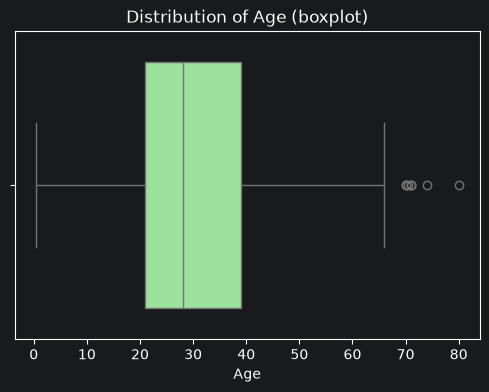

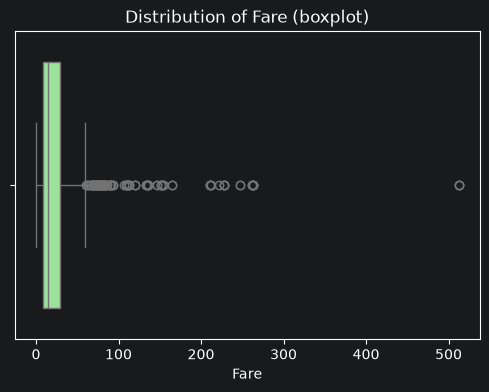

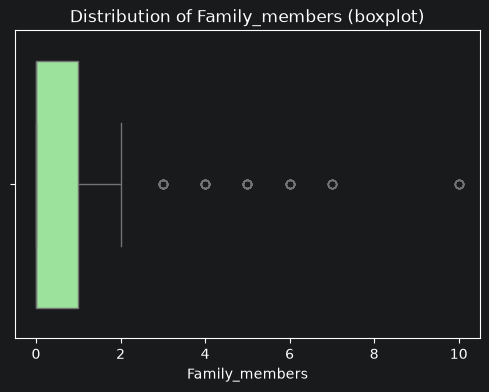

In [18]:
def boxplot(df, column_name):
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[column_name].dropna(), color='lightgreen')
    plt.title(f'Distribution of {column_name} (boxplot)')
    plt.xlabel(column_name)

    plt.show()
boxplot(titanic_df, 'Age')
boxplot(titanic_df, 'Fare')
boxplot(titanic_df, 'Family_members')

Mimo obecności outlierów, są one realne i nie wymagają modyfikacji. Pora na wizualizacje i zależności. Dla cech numerycznych najlepsza będzie heatmapa.

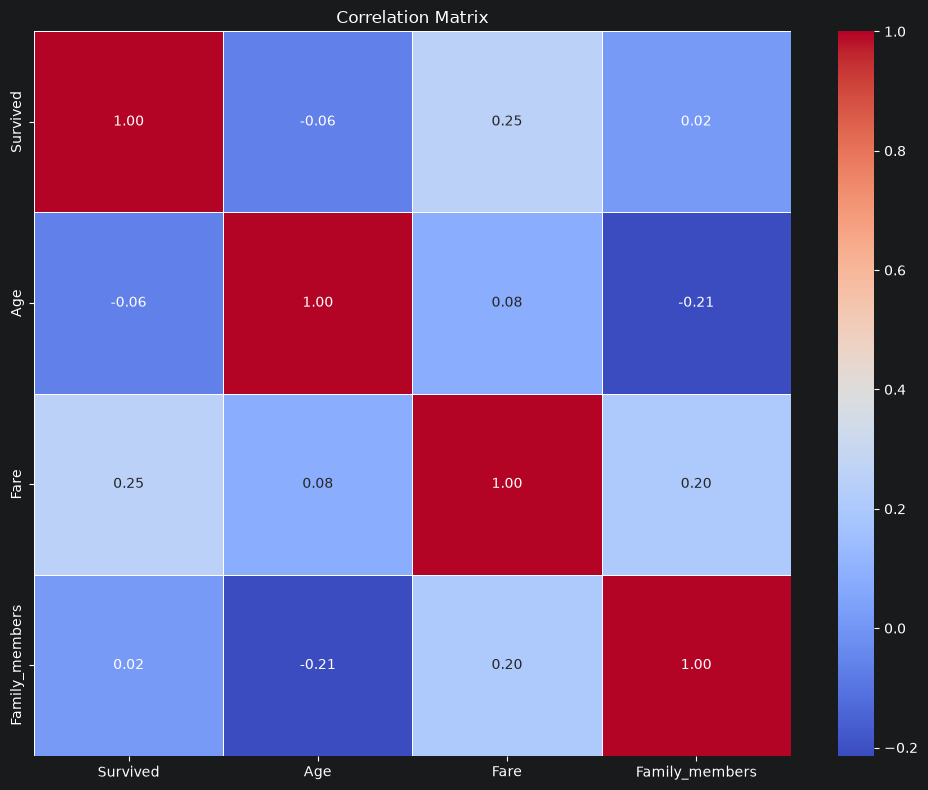

In [19]:
def plot_correlation_matrix(df, data):
    # fmt=".2f" rounds the number to 0.01
    plt.figure(figsize=(10, 8))
    sns.heatmap(data.corr(), annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
    plt.title('Correlation Matrix')
    plt.tight_layout()
    plt.show()
plot_correlation_matrix(titanic_df, titanic_df[['Survived','Age','Fare','Family_members']])

Wnioskuję, że wiek oraz wielkość rodziny nie miały za dużego wpływu na przeżywalność, a cena biletu - miała mały. Im droższy bilet, tym większa szansa na przeżycie. Teraz dane kategorialne.

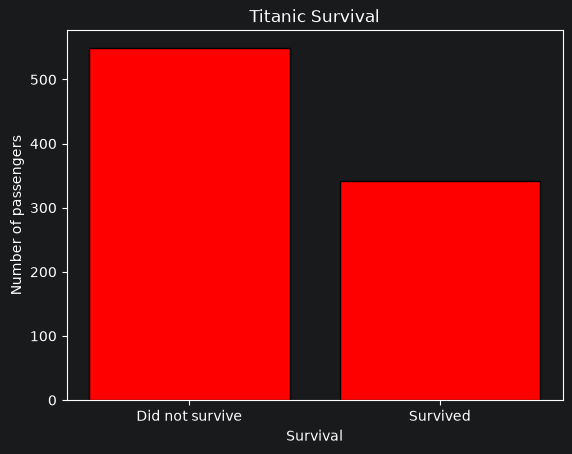

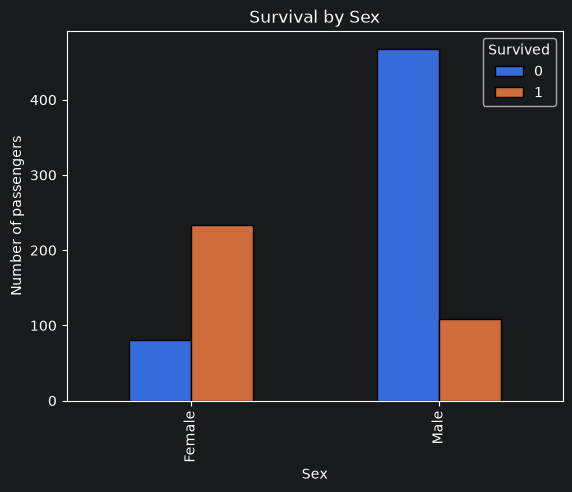

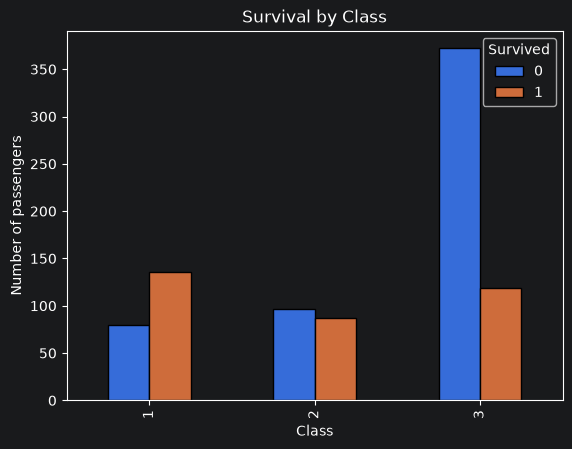

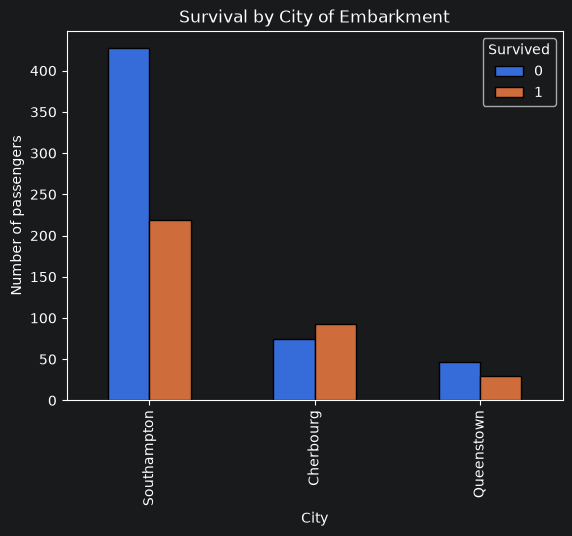

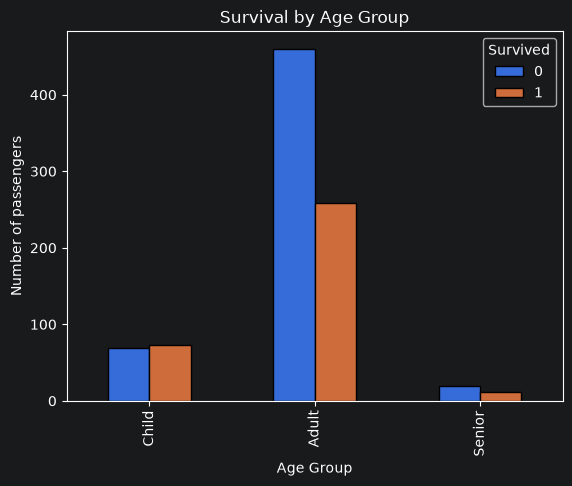

In [20]:
#Przeżycie liczbowo
categories = ['Did not survive', 'Survived']
values = titanic_df['Survived'].value_counts().sort_index()
plt.bar(categories, values, color='red', edgecolor='black')
plt.title("Titanic Survival")
plt.xlabel("Survival")
plt.ylabel("Number of passengers")
plt.show()

#Płeć
survival_by_sex = titanic_df.groupby('Is_male')['Survived'].value_counts().unstack()
survival_by_sex.index = ['Female', 'Male']
survival_by_sex.plot(kind='bar', edgecolor='black')
plt.title("Survival by Sex")
plt.xlabel("Sex")
plt.ylabel("Number of passengers")
plt.show()

#Klasa
survival_by_class = titanic_df.groupby('Pclass')['Survived'].value_counts().unstack()
survival_by_class.plot(kind='bar', edgecolor='black')
plt.title("Survival by Class")
plt.xlabel("Class")
plt.ylabel("Number of passengers")
plt.show()

#Miasto, z którego pasażerowie wsiadali
survival_by_city = titanic_df.groupby('City_index')['Survived'].value_counts().unstack()
survival_by_city.index = ['Southampton', 'Cherbourg','Queenstown']
survival_by_city.plot(kind='bar', edgecolor='black')
plt.title("Survival by City of Embarkment")
plt.xlabel("City")
plt.ylabel("Number of passengers")
plt.show()

#Grupa wiekowa
survival_by_age_group = titanic_df.groupby('Age_group_index')['Survived'].value_counts().unstack()
survival_by_age_group.index = ['Child', 'Adult','Senior']
survival_by_age_group.plot(kind='bar', edgecolor='black')
plt.title("Survival by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of passengers")
plt.show()

Większość ludzi katastrofy nie przeżyła. Kobiety okazały się silniejsze od mężczyzn i to one mają większy odsetek ocalałych w porównaniu do płci męskiej, u której zmarło dużo więcej osób niż przeżyło. Jeśli chodzi o klasy, to, bez zaskoczeń, wybór pierwszej z nich był najbardziej opłacalny i z każdą niższą odsetek ocalałych spadał. Prawdopodobnie bogatsi mieli pierwszeństwo do szalup ratunkowych, co jest zgodne z wnioskami o cenach biletów. Miasto, w którym pasażerowie wsiadali na statek nie miało większego znaczenia. Nie ma danych, które mówiłyby o pierwszeństwie względem miasta wsiadania, lepszej fizyczności itp. Zatem wszelkie potencjalne zależności z przeżywalnością są raczej przypadkowe. Możnaby było tę kolumnę usunąć. Wreszcie, grupa wiekowa. Wyniki nie zaskakują. Około połowa dzieci przeżyła, większość seniorów zmarła oraz większość dorosłych nieprzeżyła, choć oczywiście była tam również największa grupa ocalałych. Potencjalnie na sam koniec uznaję również, że mogłem usunąć kolumny o członkach rodziny, które posłużyły do stworzenia cechy Family_members. Nie są potrzebne.